<a href="https://colab.research.google.com/github/jhonegonzalezq/opti-bio/blob/main/Topicosexamendoctorado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lección 3 - Clustering de texto con LLMs pre-entrenados

En esta lección veremos cómo implementar de forma práctica un sistema de clustering de texto usando modelos pre-entrenados.

## 1. Instalación e importación de las librerías requeridas

In [1]:
!pip install datasets==4.0.0 sentence_transformers==5.2.0 umap-learn==0.5.9.post2 safetensors==0.7.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.7/493.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: umap-learn
    Found existing installation: umap-learn 0.5.11
    Uninstalling umap-learn-0.5.11:
      Successfully uninstalled umap-learn-0.5.11
  Attempting uninstall: sentence_transformers
    Found existing installation: sentence-transformers 5.2.3
    Uninstalling sentence-transformers-5.2.3:
      Successfully uninstalled sentence-transformers-5.2.3


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Lectura de datasets y del modelo pre-entrenado
from datasets import load_dataset # 4.0.0
from sentence_transformers import SentenceTransformer # 5.2.0
from safetensors.numpy import save_file, load_file # 0.7.0. Opcional para guardar y recargar embeddings obtenidos

# Reducción de dimensionalidad y clustering
from umap import UMAP # 0.5.9.post2
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score

# Exploración y visualización de datos
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap
import pandas as pd
import itertools

# Google Drive (para la lectura de los datos)
from google.colab import drive
drive.mount('/content/drive')

# Fijar semillas de generadores aleatorios
import torch
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. El problema a resolver

> Crear un sistema capaz de generar agrupaciones de textos sobre un set de datos que contiene resúmenes de artículos académicos.

## 3. El set de datos

Comencemos leyendo y haciendo una exploración inicial del set de datos.

Usaremos el set de datos [Academic Knowledge Abstracts (Spanish)](https://huggingface.co/datasets/Flaglab/academic-knowledge-abstracts-es) que contiene el título y el resumen de varios miles de artículos académicos desarrollados por investigadores de una universidad en Colombia.

Aunque el set de datos se puede descargar de HuggingFace usaremos la versión del mismo set de datos pero [almacenada en formato "parquet"](https://drive.google.com/file/d/1y8i6xDuR9DFYMZbpCF4sPm7Y9-nPF-38/view?usp=sharing).

Así que hagamos la lectura del set de datos desde Google Drive:

In [4]:
!pip install bibtexparser datasets

import bibtexparser
import pandas as pd
from datasets import Dataset

RUTA_DATOS = '/content/drive/MyDrive/scopus0203246.bib'

with open(RUTA_DATOS) as f:
    bib_db = bibtexparser.load(f)

df = pd.DataFrame(bib_db.entries)

dataset_tr = Dataset.from_pandas(df)

dataset_tr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=82e0c4c29effe08a4cea8749ff9394a8a959d992e15f704dbbc312f8feb7b787
  Stored in directory: /root/.cache/pip/wheels/54/f8/e6/ecfceb6af875ddc5096bb3811795ac336f50371009a601454d
Successfully built bibtexparser


Dataset({
    features: ['note', 'source', 'publication_stage', 'type', 'abbrev_source_title', 'language', 'publisher', 'correspondence_address', 'author_keywords', 'abstract', 'affiliations', 'url', 'doi', 'pages', 'number', 'volume', 'journal', 'year', 'title', 'author', 'ENTRYTYPE', 'ID', 'coden', 'issn', 'keywords', 'isbn', 'pmid'],
    num_rows: 230
})

In [9]:
RUTA_DATOS = '/content/drive/MyDrive/scopus0203246.bib'

# Leer dataset de entrenamiento
dataset_tr = load_dataset("bib",
                          data_files=f"{RUTA_DATOS}/scopus0203246.bib",
                          split="train")
dataset_tr

DatasetNotFoundError: Dataset 'bib' doesn't exist on the Hub or cannot be accessed.

El set de datos contiene un total de 10.021 registros, número que resulta adecuado para construir nuestro sistema de "clustering".

Extraigamos los campos "titulo" y "resumen":

In [10]:
resumenes = dataset_tr['abstract']
titulos = dataset_tr['title']

Y veamos algunos ejemplos de los textos:

In [11]:
# Extraer un índice aleatorio
N = len(resumenes)
idx = random.randint(0, N)

# Extraer texto y darle formato
texto = resumenes[idx]
texto = textwrap.fill(texto, 100)

# Imprimir título y resumen
print(f"Título: {titulos[idx]}")
print('-'*25)
print(f"Resumen: {texto}")

Título: Stochastic techno-economic evaluation model for biomass supply chain: A biomass gasification case study with supply chain uncertainties
-------------------------
Resumen: Sustainable development has been a goal for many industries, which can be achieved via the
substitution of non-renewable feedstocks with greener alternatives such as substituting coal with
biomass for gasification process. The sustainably produced biomass-derived syngas has a lower carbon
emission when utilized as a fuel. Although most studies have reported the possible impact of biomass
quality on the feasibility of biomass conversion process, there is still little published works on
the incorporation of biomass quality directly into developed mathematical evaluation model.
Therefore, this paper aims to perform techno-economic feasibility evaluation on biomass gasification
process, with the consideration of various supply chain uncertainties via Monte Carlo simulation
(i.e., biomass supply, biomass quality, b

Vemos que los resúmenes pueden tener longitudes diferentes.

Como usaremos un LLM, debemos determinar los tamaños que pueden llegar a tener los textos (en número de palabras) para determinar si estos se ajustan o no a la ventana de contexto del modelo que usaremos:

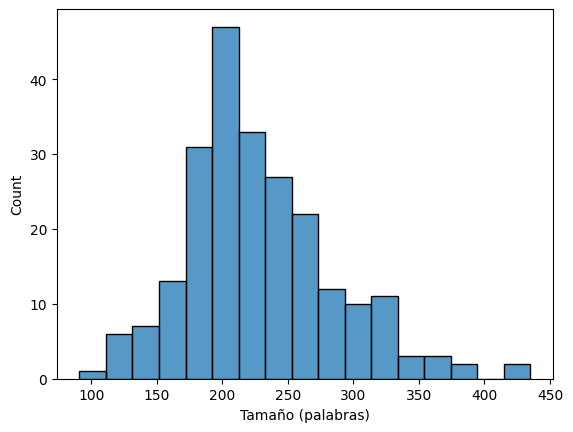

In [12]:
# Tamaños de los textos
sizes = []
for text in resumenes:
    words = text.split()
    sizes.append(len(words))

# Histograma
sns.histplot(sizes)
plt.xlabel("Tamaño (palabras)");

La gran mayoría de los textos está por debajo de las 500 palabras, aunque existen textos de más de 1.000 o incluso de 3.000 palabras.

Si asumimos una equivalente de 1 token = 0.75 palabras, tendríamos:

- 500/0.75 = 666.7 tokens en promedio
- Y algunos textos tendrán 1.000/0.75 = 1333.3 o incluso 3.000/0.75 = 4.000 tokens

Los modelos que usaremos no logran cubrir la cantidad máxima de tokens, así que las secuencias serán truncadas **y debemos tener en cuenta que esto será una limitación de nuestra implementación**

> Nota: podríamos usar un modelo con una ventana de contexto mayor pero esto incrementa los recursos computacionales necesarios para su ejecución.

## 4. El LLM

Como lo vimos en la lección anterior, usaremos un modelo de representación pre-entrenado.

Para elegir el modelo debemos tener en cuenta características como:

- La ventana de contexto y el tamaño de las secuencias a usar
- Número de parámetros del modelo (entre más parámetros mayor RAM y mayores capacidades de cómputo se requieren)
- El modelo debería haber sido pre-entrenado para tareas similares y para el lenguaje en el que están los datos (o al menos multilenguaje)
- Formato de almacenamiento: 16 bits idealmente (para agilizar el procesamiento)

Una opción que podemos usar para encontrar un modelo adecuado es acceder a la [MTEB leaderboard de HuggingFace](https://huggingface.co/spaces/mteb/leaderboard) que nos permite comparar en tiempo real el desempeño de diferentes modelos de "embedding" de texto.

En este caso usaremos [google/embeddinggemma-300m](https://huggingface.co/google/embeddinggemma-300m) que tiene un buen desempeño en el Leader Board.

> Nota: en caso de que las capacidades de procesamiento no sean suficientes, se sugiere como alternativa el modelo [sentence-transformers/sentence-t5-base](https://huggingface.co/sentence-transformers/sentence-t5-base)


Algunas características del modelo que usaremos:

- 300 millones de parámetros
- Formato de almacenamiento: 32 bits (lo podemos forzar a 16 para reducir requerimientos de RAM)
- Multilenguaje
- Cada embedding generado es de 768 elementos
- Ventana de contexto de 2048 tokens

Este modelo resultará adecuado para esta tarea de agrupamiento de texto y además no exigirá demasiados recursos en Google Colab.

Comencemos cargando este modelo:

In [13]:
RUTA_MODELO = 'intfloat/e5-base-v2'
# RUTA_MODELO = 'sentence-transformers/sentence-t5-base' # Modelo alternativo
embedding_model = SentenceTransformer(RUTA_MODELO)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Y veamos sus características:

In [14]:
embedding_model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 512, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

Vemos que efectivamente:

- La ventana de contexto (max_seq_length) es de 2048 tokens
- El tamaño del embedding generado (out_features) es de 768

Con el modelo listo y los datos ya cargados, podemos obtener los "embeddings". Acá **es clave habilitar la GPU que provee Google Colab**:

In [15]:
embeddings = embedding_model.encode(resumenes, show_progress_bar=True)

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Por defecto el modelo **trunca automáticamente los resúmenes que sobrepasan los 2048 tokens**.

Veamos las características de los "embeddings":

In [16]:
print("Ejemplo de un 'embedding':")
print(embeddings[10])
print("-"*20)
print(f"Tamaño de los embeddings: {embeddings.shape}")

Ejemplo de un 'embedding':
[-2.65482180e-02 -6.56350777e-02 -6.47151545e-02 -1.21697467e-02
  3.36257927e-02 -4.77016605e-02 -2.03706119e-02  4.94392812e-02
 -3.33109982e-02 -3.02469730e-02 -5.90031315e-03  1.90334078e-02
 -5.98746128e-02  1.79990064e-02 -5.62466532e-02  6.53045326e-02
  3.64411697e-02 -8.85441434e-03  1.13594737e-02 -8.22349545e-03
 -4.43087295e-02 -3.76964621e-02  3.39693651e-02  4.93297204e-02
 -1.49320858e-03  1.94537602e-02 -8.31338484e-03  4.88776453e-02
 -2.72613689e-02 -3.83816026e-02  2.37159003e-02  2.88959946e-02
  2.74677854e-02 -3.11456602e-02 -2.89456155e-02  4.94247004e-02
 -9.12094787e-02 -5.03127612e-02 -7.49495924e-02 -1.80486590e-02
 -2.87784114e-02 -6.78253453e-03 -5.45986630e-02  5.25003336e-02
  3.86612699e-03 -3.11381221e-02 -5.87737411e-02  6.77888021e-02
 -3.28870304e-02 -3.34787667e-02 -6.83873519e-02 -4.04275721e-04
  1.53010488e-02 -3.76045853e-02 -2.78067067e-02  1.72508303e-02
  7.37028196e-03 -2.70224642e-02 -2.02253070e-02 -5.61475419e-0

Una opción, para evitar el uso excesivo de la GPU, es almacenar en disco los "embeddings" obtenidos:

In [17]:
# Guardar con "safetensors"
save_file({"embeddings": embeddings}, "embs_resumenes_esp_tr.safetensors")

Y si más adelante queremos recargar los "embeddings" usamos las siguientes líneas de código:

In [ ]:
loaded = load_file("/content/drive/MyDrive/embs_resumenes_esp_tr.safetensors")
embeddings = loaded["embeddings"]

## 5. Reducción de dimensionalidad de los "embeddings"

Como acabamos de ver, los embeddings generados tienen una alta dimensionalidad (768) lo cual no resulta adecuado para un algoritmo/modelo de clustering.

Así que debemos **reducir la dimensionalidad de cada embedding** para obtener mejore resultados.

Aunque el [Análisis de Componentes Principales](https://codificandobits.com/curso/probabilidad-nivel-avanzado/5-analisis-componentes-principales-explicacion-detallada/), que vimos en detalle en la lección 5 del curso Probabilidad Nivel Avanzado, es una alternativa, en este caso usaremos el método UMAP (*Uniform Manifold Approximation and Projection*) que logra preservar mejor la "esencia" de los embeddings a medida que se reducen las dimensiones.

Generalmente, la dimensionalidad que se busca está entre 5 y 10 y de hecho **la dimensionalidad de los embeddings reducidos es un hiper-parámetro** de este sistema de *clustering*.

Usaremos una dimensionalidad de 5 pero se sugiere probar con otros valores (8 o 10) para ver el efecto que esto tiene en las agrupaciones generadas:

In [18]:
umap_model = UMAP(
    n_components=5, # Nueva dimensionalidad (comprimir de 768 a 5)
    min_dist=0.0, # Si dos resúmenes son muy similares codificarlos prácticamente de la misma forma
    metric='cosine', # Usar similitud del coseno para cuantificar distancia entre "embeddings"
    random_state=42, # Fijar semilla para reproducibilidad de los resultados
    n_jobs = 1 # Para reproducibilidad de los resultados
)
embeddings_reducidos = umap_model.fit_transform(embeddings)

En este punto tendremos la misma cantidad de embeddings original, pero ahora en lugar de usar vectores de 768 elementos para representarlos usaremos vectores de 5 elementos:

In [19]:
embeddings_reducidos.shape

(230, 5)

Perfecto, en este punto ya estamos listos para aplicar el algoritmo de *clustering*.

## 6. Clustering del texto

En este punto viene una elección clave en el diseño: el algoritmo a usar.

En el curso "Clustering en el Machine Learning" analizamos en detalle los principales algoritmos de "clustering" de datos pero acá nos enfocaremos en los pros y los contras para poder decidir cuál es el método más adecuado **en el contexto del "clustering" de texto**:

- k-means:
    - 🔻 debemos introducir el número de agrupaciones
    - 🔻 asume que las agrupaciones son simétricas con respecto al centroide (lo cual no ocurre en el texto)

- DBSCAN:
    - 🔻 debemos definir el parámetro "epsilon"
    - 🔻 asume que todos los "clusters" tienen densidades similares (lo cual no ocurre en el texto)
- Modelos de mezcla gaussiana:
    - 🔻 asume que la distribución de las agrupaciones se puede explicar como la combinación de distribuciones gaussianas multidimensionales (lo cual no ocurre en el texto)
- Jerárquico:
    - 👍 Define una estructura jerárquica que permite separar una agrupación de otra (adecuado cuando tenemos diferentes temáticas en el texto)
    - 🔻 Pero tiene un costo computacional alto
- HDBSCAN:
    - 👍 Define una estructura jerárquica que permite separar una agrupación de otra (adecuado cuando tenemos diferentes temáticas en el texto)
    - 👍 Pero además es capaz de generar agrupaciones con diferentes densidades
    - 👍 Y su costo computacional es menor en comparación con el clustering jerárquico

> Conclusión: en tareas de "clustering" de texto **generalmente el método HDBSCAN es el más usado**.

Para implementar este método debemos definir dos hiper-parámetros (ver lección 6 del curso "Clustering en el Machine Learning"):

- "min_samples": cuántos puntos vecinos de otro punto se consideran para determinar si dicho punto es "core". Entre más grande sea "min_samples" más puntos etiquetados como ruido (-1) tendremos
- "min_cluster_size": el número mínimo de datos para considerar que tenemos un "cluster"

Y lo que nos interesa es **encontrar una combinación adecuada de hiper-parámetros que retorne un puntaje silueta adecuado y que a la vez no genere un número elevado de "outliers"**.

Así que seguiremos este procedimiento:

1. Definiremos un rango de valores para "min_samples" y para "min_cluster_size"
2. Por cada combinación de valores de estos dos hiper-parámetros:
    - Construiremos un modelo HDBSCAN
    - Calcularemos y almacenaremos el puntaje silueta, el porcentaje de "outliers" y el número de agrupaciones generadas
3. Al final buscaremos una combinación de hiper-parámetros donde el puntaje silueta resulte adecuado (mayor que 0.5), el porcentaje de "outliers" no sea tan elevado y el número de clusters no resulte ni excesivamente pequeño ni excesivamente grande

Veamos esta implementación:

In [20]:
# Combinatoria de MS y MCS
MS = range(2, 31, 4) # 2, , 6, ... 30
MCS = range(2, 31, 4) # 2,  6,... 30

# Todos los posibles pares de combinaciones
pares = list(itertools.product(MS, MCS))
npares = len(pares)

resultados = []
for i, par in enumerate(pares):
    print(f"Probando combinación {i+1}/{npares} ({par})...")
    ms, mcs = par[0], par[1]
    hdb = HDBSCAN(min_samples=ms, min_cluster_size=mcs).fit(embeddings_reducidos)
    labels = hdb.labels_

    # Calcular porcentaje de ruido
    pctj_ruido = np.sum(labels == -1) / len(labels)

    # Calcular puntaje silueta sólo en datos que no sean ruido
    idx = labels != -1
    if np.sum(idx) > 0:
        n_clusters = len(set(labels[idx]))
        if n_clusters > 1:
            score = silhouette_score(embeddings_reducidos[idx], labels[idx])
            resultados.append({'min_samples': ms, 'min_cluster_size': mcs,
                               'silueta': score, 'ruido': pctj_ruido, 'n_clusters': n_clusters})

# Crear dataframe de resultados y ordenar por puntaje silueta
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('silueta', ascending=False)

Probando combinación 1/64 ((2, 2))...
Probando combinación 2/64 ((2, 6))...
Probando combinación 3/64 ((2, 10))...
Probando combinación 4/64 ((2, 14))...
Probando combinación 5/64 ((2, 18))...
Probando combinación 6/64 ((2, 22))...
Probando combinación 7/64 ((2, 26))...
Probando combinación 8/64 ((2, 30))...
Probando combinación 9/64 ((6, 2))...
Probando combinación 10/64 ((6, 6))...
Probando combinación 11/64 ((6, 10))...
Probando combinación 12/64 ((6, 14))...
Probando combinación 13/64 ((6, 18))...
Probando combinación 14/64 ((6, 22))...
Probando combinación 15/64 ((6, 26))...
Probando combinación 16/64 ((6, 30))...
Probando combinación 17/64 ((10, 2))...
Probando combinación 18/64 ((10, 6))...
Probando combinación 19/64 ((10, 10))...
Probando combinación 20/64 ((10, 14))...
Probando combinación 21/64 ((10, 18))...
Probando combinación 22/64 ((10, 22))...
Probando combinación 23/64 ((10, 26))...
Probando combinación 24/64 ((10, 30))...
Probando combinación 25/64 ((14, 2))...
Proband

Veamos gráficamente cómo se comportan el puntaje silueta y el porcentaje de "outliers" según las combinaciones ordenadas del mayor puntaje silueta al menor:

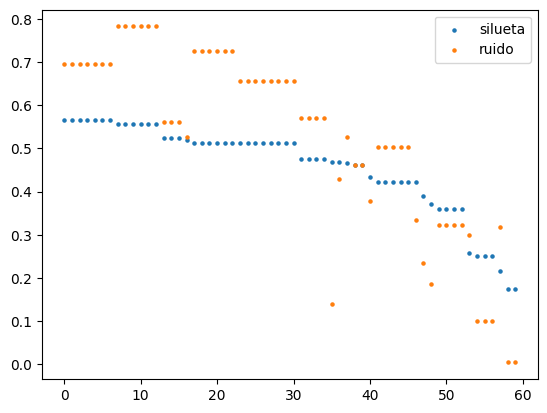

In [21]:
plt.scatter(range(len(df_resultados)),df_resultados['silueta'],s=5, label='silueta')
plt.scatter(range(len(df_resultados)),df_resultados['ruido'],s=5, label='ruido')
plt.legend();

Observamos que:

- Para las peores combinaciones (posiciones de ~50 en adelante) el puntaje silueta se estabiliza en aproximadamente 0.4 y el ruido es prácticamente nulo
- Y tanto el puntaje como el porcentaje de ruido van disminuyendo proporcionalmente

Veamos los top-25 resultados para incluir el número de agrupaciones en el análisis:

In [22]:
df_resultados.head(25)

,min_samples,min_cluster_size,silueta,ruido,n_clusters
36,18,18,0.565367,0.695652,2
33,18,6,0.565367,0.695652,2
35,18,14,0.565367,0.695652,2
34,18,10,0.565367,0.695652,2
38,18,26,0.565367,0.695652,2
37,18,22,0.565367,0.695652,2
39,18,30,0.565367,0.695652,2
56,30,10,0.556709,0.782609,2
54,30,2,0.556709,0.782609,2
55,30,6,0.556709,0.782609,2


Observamos que:

- El número de clusters oscila aproximadamente entre 60 y 200 datos/cluster
- Para este top-25 el puntaje silueta en todos los casos es superior a 0.6 (un muy buen valor teniendo en cuenta que se trata de texto)
- Mientras que el porcentaje de ruido oscila entre 0.4 y 0.5 (40-50%)

Busquemos combinaciones donde el porcentaje de ruido sea aún menor:

In [24]:
# Filtrar niveles de ruido menores a 0.4
df_resultados[df_resultados['ruido'] < 0.5]

,min_samples,min_cluster_size,silueta,ruido,n_clusters
0,2,2,0.468663,0.139130,57
11,6,14,0.468537,0.430435,4
19,10,14,0.461169,0.460870,5
18,10,10,0.461169,0.460870,5
10,6,10,0.433029,0.378261,5
3,2,14,0.422315,0.334783,6
2,2,10,0.390411,0.234783,10
1,2,6,0.370961,0.186957,14
12,6,18,0.358793,0.321739,2
13,6,22,0.358793,0.321739,2


10	30	0.521155	0.375911


Así que buscaremos la combinación con el menor porcentaje de ruido y un número no tan elevado de clusters (para facilitar la interpretación del contenido).

Por tanto escogeremos la combinación min_samples = 10 y min_cluster_size=30, que arroja un puntaje silueta de 0.52, un nivel de ruido de 37.5% y un total de 70 clusters. Construyamos el modelo con estos parámetros:

In [25]:
hdbscan = HDBSCAN(min_samples=2, min_cluster_size=2)
clusters = hdbscan.fit_predict(embeddings_reducidos)
clusters

array([ 8, 16,  1, -1, 52, 44, 49, -1, 18, 36, 43,  1, -1, 12,  9, 38,  8,
       -1, 54, 56, -1, 33, 39, 29, 54, 32, 16, 12, 34, 46, 23, -1, 48, 28,
       -1, 44, 48, -1, -1, 54, -1, -1, 25, 21,  7, 13, 15, 49, 32, 13, 35,
       12, 16, 16,  2, -1, 51, -1, -1, 16, -1, -1, 52, 30, 42, 28, 29, 43,
       44, 26, 14, 54, 54,  3, 47, 24, 55, 17, 26, 28, 23, 41, 17, 32, 16,
        7, 44,  6, 35, -1,  5, 25, 20, -1, 31, 50, 54, 38, -1,  2,  4, 42,
       51, 53, -1, 43, 11, 17, 19, 53,  5, 14, 37, 29,  2, 35,  2, 33, 20,
       18, 47, 44, 16, 16, -1, 42, -1, 29, 45, 37,  8, 27, 50, 50, 25,  4,
       17,  3, 10, 56, 16,  0, 55,  3, 24, -1,  0, 45, 40, 22, 30,  4, 36,
       47,  0,  6,  3, 12, 21, 45, 27,  0, 22, 45, 46,  0, 38, -1, -1,  0,
       13,  3, 30, 53,  4, 14,  0, 21, 39, 31, 22, 16, 34, 16, 16, 34, 41,
       39, 20, 26, 44, 22, 19, -1, -1, 29, 27, 35, 52, 19, 40, 34, 16,  6,
       16,  9, 46,  8, 42, -1,  9, 10, 15, -1, 21, 33, 15, 55, 54, 33, -1,
       43, -1, 16, 11,  4

Los "outliers" ("textos aislados") son etiquetados con -1.

Veamos el número de clusters generados incluyendo precisamente los "outliers":

In [26]:
len(set(clusters))

58

Esto quiere decir que tendremos 71 diferentes agrupaciones de textos. Verifiquemos el porcentaje de "outliers":

In [27]:
# Porcentaje de outliers
pctj_outliers = np.sum(clusters == -1) / len(clusters)
print(f"Porcentaje de outliers: {100*pctj_outliers:.1f} %")

Porcentaje de outliers: 13.9 %


## 7. Exploración de los "clusters" generados

Lo primero que debemos analizar es si todas las agrupaciones (no "outliers") tienen más o menos la misma cantidad de datos:

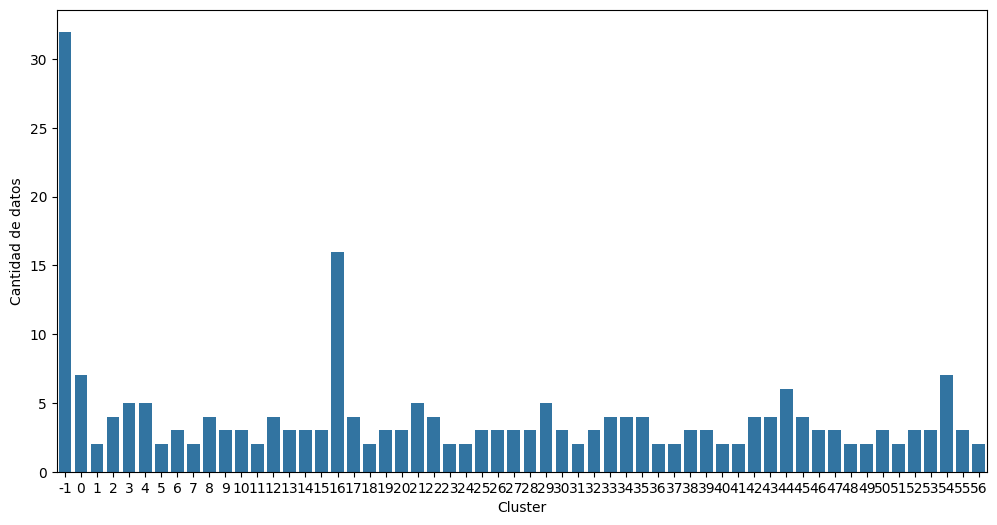

In [28]:
# Distribución de las agrupaciones
fig, ax = plt.subplots(figsize=(12,6))
df_clusters = pd.Series(clusters).value_counts()
sns.barplot(x=df_clusters.index, y=df_clusters.values)
ax.set_xlabel('Cluster')
ax.set_ylabel('Cantidad de datos');

Desde luego el número de outliers (37.6%) supera la cantidad de datos en cada cluster. Sin embargo, el número de datos en cada cluster está entre 50 y 500 aproximadamente, es decir que no tenemos clusters con demasiados datos ni otros con muy pocos.

Otra manera de explorar los resultados es tomar diferentes clusters e imprimir en pantalla algunos textos que hagan parte de ellos:

In [29]:
# Exploración
label = 0 # outliers
#label = 4

idxs = np.where(clusters==label)[0]

for i in range(3):
    idx = np.random.choice(idxs).item()
    resumen = resumenes[idx]
    resumen = textwrap.fill(resumen, width=100)
    print(f"--- Documento {idx} ---")
    print(resumen)
    print("\n")

--- Documento 176 ---
The Coronavirus Disease 2019 (COVID-19) instigated a pandemic that impacted economies, employment,
and shipping worldwide. This paper reviews how one international supply chain performed and
identifies lessons that may be helpful to improve future resilience. Economic and employment data
through November 2020 are used to review the effects of COVID-19 on operations of the bioenergy
supply chain in the southeastern United States (SE United States) that utilizes wood fiber to
fabricate pellets. Conditions associated with the production of pellets in the SE United States
changed with the outbreak of COVID-19. Federal and state government programs and classification of
workers in this sector as “essential” during the pandemic helped maintain the woody pellet supply
chain and other industries during a period of general shut down in 2020. The availability of
personal protective equipment, long-term supply contracts, and established safety cultures are among
the factors 

Observamos que:

- Para el caso de los "outliers" generalmente los textos mostrados no guardan relación semántica entre sí lo que indica una diferenciación adecuada
- Mientras que al analizar los "clusters" se observan temáticas semánticamente similares
- Sin embargo, algunos "outliers" podrían hacer parte de ciertos clusters y esto es precisamente una limitación del "clustering" de texto: **no es perfecto pues el texto puede contener ambigüedades, o puede abordar múltiples temáticas y por tanto en ocasiones no podrá ser asignado a ninguna agrupación**

También podemos reducir la dimensionalidad de los embeddings a 2 y hacer un gráfico de dispersión 2D de los "outliers" y de las agrupaciones obtenidas:

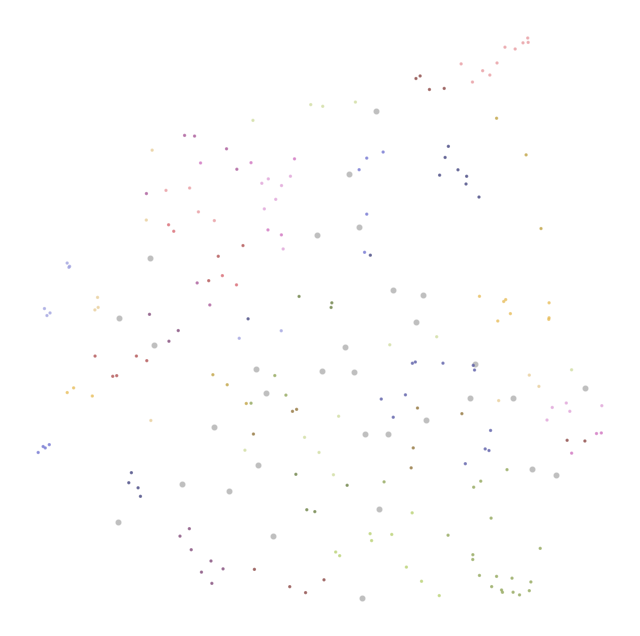

In [30]:
# Exploración como gráficos 2d
embeddings_2D = UMAP(
    n_components = 2,
    min_dist = 0.0,
    metric = "cosine",
    random_state = 42,
    n_jobs = 1
).fit_transform(embeddings)

# Crear un DataFrame con la información 2D
df = pd.DataFrame(embeddings_2D, columns=["x", "y"])
df["titulo"] = titulos
df["cluster"] = [str(c) for c in clusters]

# Crear dataframes de clusters y de outliers
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

# Y hacer gráficos de dispersión
fig, ax = plt.subplots(figsize=(8,8))
sns.scatterplot(outliers_df, x="x", y="y", alpha=0.5, s=20,
            c="grey")
plt.scatter(clusters_df.x, clusters_df.y,
            c=clusters_df.cluster.astype(int),
            alpha=0.6, s=2, cmap="tab20b")
plt.axis("off");

In [31]:
clusters_df

,x,y,titulo,cluster
0,0.769072,0.281391,Carbon dioxide removal potential of biochar wi...,8
1,4.201913,-0.854258,Biomass procurement and supplier diversificati...,16
2,3.150841,1.892510,What's new in biomass supply chain optimizatio...,1
4,4.644261,0.208926,Resilient biomass-based CHP system design unde...,52
5,4.090665,3.527453,Biomass supply chain coordination considering ...,44
...,...,...,...,...
224,2.178187,1.185943,Cost-effectiveness of small scale biomass supp...,11
225,4.002896,0.244974,Hybrid optimization-simulation for integrated ...,4
226,2.770269,0.214926,Performance indicators for poultry manure supp...,21
228,4.257565,-0.996456,A simple tool for resource availability optimi...,16


Y podemos observar que:

- Hay clusters bastante alejados los unos de los otros, lo que nos indica la presenta de temáticas bastante diferentes
- Pero otros están muy cerca (temáticas similares)
- De igual forma, algunos textos "outliers" están muy lejos (realmente son "outliers") mientras que otros están en la frontera de múltiples "clusters". **Este es precisamente uno de los retos del "clustering" de texto: en ocasiones, por las mismas características del lenguaje natural, no resultará posible asignar un texto a una única agrupación**

Y es por esta última razón que precisamente tenemos tantos "outliers", porque muy probablemente los resúmenes de los textos no abordan una única temática en muchos casos.

> Nota: en todo caso debemos también tener en cuenta que la reducción de dimensionalidad implica pérdida de información. Así que como estamos usando 2 dimensiones **debemos ser cautos** al momento de extraer cualquier conclusión

## 8. Ventajas y limitaciones del "clustering" de texto

- 🟢 La principal ventaja es que de forma automática podremos agrupar textos semánticamente similares.
- 🟢 Lo anterior permite reducir la cantidad de trabajo "manual" que se debería hacer en situaciones donde la cantidad de textos es elevada
- 🔴 Las propias características de los textos en el set de datos pueden hacer que no existan agrupaciones perfectamente diferenciadas y que por tanto existan textos que no pertenecerán a una agrupación en particular ("outliers")
- 🔴 Dadas estas variaciones en los textos, no existe una manera totalmente certera de escoger la mejor combinación de hiper-parámetros en el algoritmo de "clustering"
- 🔴 El "clustering" nos arroja las agrupaciones pero no nos dice cuáles son los tópicos de dichas agrupaciones

In [32]:
!pip install bertopic==0.17.4 nltk==3.9.1 langdetect==1.0.9

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 55.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 18.2 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=45f11fc73a0b316ac56c4863858bbbc87a3b23ed218c36319983588971d8f48e
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [33]:
# Lectura de datasets y del modelo pre-entrenado
from datasets import Dataset, load_dataset # 4.0.0
from sentence_transformers import SentenceTransformer # 5.2.0
from safetensors.torch import load_file # 0.2.0

# Reducción de dimensionalidad, clustering y modelado de tópicos
from umap import UMAP # 0.5.9.post2
from sklearn.cluster import HDBSCAN
from bertopic import BERTopic

# Procesamiento adicional del texto
from langdetect import detect
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Google Drive (para la lectura de los datos)
from google.colab import drive
drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. El problema a resolver
Usar BERTopic para realizar el modelado de tópicos del set de datos usado en la lección 3 (resúmenes académicos)

> Agregar bloque entrecomillado



In [34]:
# Crear instancia de BERTopic especificando únicamente el método de clustering
topic_model = BERTopic(
    # embedding_model=embedding_model,
    # top_n_words = 5 # el número de palabras clave a extraer por cada tópico (10 por defecto)
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    verbose=True)
topic_model.fit(resumenes)

2026-03-09 04:45:17,429 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

2026-03-09 04:45:27,147 - BERTopic - Embedding - Completed ✓
2026-03-09 04:45:27,149 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 04:45:27,668 - BERTopic - Dimensionality - Completed ✓
2026-03-09 04:45:27,670 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 04:45:27,681 - BERTopic - Cluster - Completed ✓
2026-03-09 04:45:27,686 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 04:45:28,331 - BERTopic - Representation - Completed ✓


In [35]:
loaded = load_file("/content/embs_resumenes_esp_tr.safetensors")
embeddings = loaded["embeddings"]

# Y a continuación usamos BERTopic pero no usamos el argumento "embedding_model" (para no recalcular los "embeddings"):

In [36]:
# Crear instancia de BERTopic especificando únicamente el método de clustering
topic_model = BERTopic(
    # embedding_model=embedding_model,
    # top_n_words = 5 # el número de palabras clave a extraer por cada tópico (10 por defecto)
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    verbose=True)

topic_model.fit(resumenes, np.array(embeddings));

2026-03-09 04:46:03,430 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 04:46:04,494 - BERTopic - Dimensionality - Completed ✓
2026-03-09 04:46:04,497 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 04:46:04,530 - BERTopic - Cluster - Completed ✓
2026-03-09 04:46:04,543 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 04:46:04,763 - BERTopic - Representation - Completed ✓


¡Y listo, ya se ha realizado el modelado de tópicos básico con BERTopic!

# 5. Exploración de los tópicos creados
Podemos comenzar usando "get_topic_info()" para mostrar en pantalla un DataFrame con la información general de cada tópico obtenido:

In [37]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,32,-1_and_the_of_to,"[and, the, of, to, in, for, biomass, by, that,...",[Even though biomass is characterised as renew...
1,0,16,0_milp_model_the_is,"[milp, model, the, is, of, to, and, biomasssol...",[Biofuel is one of the emerging sources of ren...
2,1,7,1_this_agroforestry_recovery_residual,"[this, agroforestry, recovery, residual, fire,...",[Sustainability is under threat due to ineffic...
3,2,7,2_pandemic_covid19_pellet_supply,"[pandemic, covid19, pellet, supply, the, resil...",[The novel coronavirus (COVID-19) is highly de...
4,3,6,3_subsidies_government_subsidy_power,"[subsidies, government, subsidy, power, welfar...",[Purpose – The purpose of this paper is to inv...
5,4,5,4_supply_to_framework_chain,"[supply, to, framework, chain, flexibility, an...","[To design and deploy their supply chains, com..."
6,5,5,5_social_hubandspoke_solution_bsc,"[social, hubandspoke, solution, bsc, proposed,...",[Most of methodologies for evaluating supply c...
7,6,5,6_forestbased_variations_model_robust,"[forestbased, variations, model, robust, tacti...",[Production of bioenergy and biofuels from for...
8,7,5,7_feedstock_of_with_biomass,"[feedstock, of, with, biomass, for, biorefiner...",[Biomass feedstock is a key sustainable altern...
9,8,4,8_residues_california_bioenergy_residue,"[residues, california, bioenergy, residue, pot...",[This paper determines the potential of instal...


Observaciones:
# Sección nueva
Tendremos más de 80 clusters + outliers (número de filas DataFrame)
La columna "Count" indica el número de documentos (resúmenes) en cada cluster
"Name" es simplemente un nombre que se le da a cada cluster
"Representation" es la columna de interés. Contiene las palabras clave de cada tópico
"Representative_Docs" contiene algunos documentos representativos de cada tópico
Sin embargo, vemos varias características no ideales en los tópicos obtenidos:

Algunos textos están en Inglés. Al tener dos idiomas en el corpus los bloques "CountVectorizer" y c-TF-IDF de BERTopic no arrojarán resultados adecuados
Algunos tópicos sólo contienen conectores (la, los, de, con, se, etc.). ¡Esto no es adecuado, pues realmente no sabremos cuáles son los tópicos en el cluster de interés!
Algunas palabras clave en ciertos tópicos no tienen el acento en Español (ejemplo: "aerolnea" en lugar de "aerolínea")
Así que veamos cómo mejorar los tópicos obtenidos.

# 6. Mejorando los tópicos obtenidos
6.1. Limpieza de corpus: únicamente texto en Español
Esto es clave pues garantizará que los bloques de modelado de tópicos extraigan adecuadamente las palabras clave.

Usaremos "langdetect" para detectar el idioma y preservar únicamente los textos en Español:

6.2. No incluir conectores y garantizar que se preservan los acentos
# Para esto debemos:

Usar un "CountVectorizer" que no tenga en cuenta dichos conectores (que formalmente se conocen como "stop words")
Al entrenar BERTopic debemos indicarle que el lenguaje de los documentos es Español
Veamos el primer paso. Comencemos usando NLTK para descargar un listado pre-definido de "stop words" para el lenguaje Español:

In [38]:
# Descargar listado de stop words en Español
nltk.download('stopwords')
stop_words = stopwords.words('english')
stop_words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

¡Perfecto!

Ahora la idea es:

Que los embeddings no sufran modificación alguna, pues los conectores son claves para que el LLM codifique correctamente el contenido de cada resumen.
Así que usaremos los mismos embeddings anteriores pero modificaremos el CountVectorizer usado por BERTopic para indicarle que no debe tener en cuenta las "stop words" que acabamos de definir
Para eso usamos el módulo "CountVectorizer" de Scikit-Learn que precisamente nos permite definir un listado de "stop words":

In [39]:
vectorizer_model = CountVectorizer(
    stop_words=stop_words,
    strip_accents=None)

Y ahora simplemente creamos nuevamente una instancia de BERTopic especificando:

El "CountVectorizer" que acabamos de crear (argumento "vectorizer_model"
Que el lenguaje del corpus será Español

In [40]:
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    vectorizer_model=vectorizer_model, ### Clave: NO CAMBIAR EMBEDDINGS, EN LOS EMBEDDINGS SÍ SE USAN LOS STOP WORDS
verbose=True)

topic_model.fit(resumenes, np.array(embeddings)); # <--- clave: usar los embeddings de textos sólo en español

2026-03-09 04:46:33,790 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 04:46:34,350 - BERTopic - Dimensionality - Completed ✓
2026-03-09 04:46:34,351 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 04:46:34,362 - BERTopic - Cluster - Completed ✓
2026-03-09 04:46:34,365 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 04:46:34,454 - BERTopic - Representation - Completed ✓


Usemos "get_topic_info()" para dar una mirada inicial a los tópicos creados:

In [41]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,32,-1_biomass_model_supply_chain,"[biomass, model, supply, chain, maintenance, u...",[As the global demand for fossil-based product...
1,0,16,0_milp_model_biomasssolid_linear,"[milp, model, biomasssolid, linear, iblc, desi...",[Extensive studies are conducted to investigat...
2,1,7,1_agroforestry_recovery_residual_fire,"[agroforestry, recovery, residual, fire, fires...",[Sustainability is under threat due to ineffic...
3,2,7,2_pandemic_covid19_pellet_resilience,"[pandemic, covid19, pellet, resilience, sector...",[This research investigates how biomass supply...
4,3,6,3_subsidies_government_subsidy_welfare,"[subsidies, government, subsidy, welfare, powe...",[Purpose – The purpose of this paper is to inv...
5,4,5,4_supply_framework_flexibility_chain,"[supply, framework, flexibility, chain, predic...","[To design and deploy their supply chains, com..."
6,5,5,5_hubandspoke_social_solution_bsc,"[hubandspoke, social, solution, bsc, bscs, nsg...",[Most of methodologies for evaluating supply c...
7,6,5,6_forestbased_variations_robust_model,"[forestbased, variations, robust, model, tacti...",[Producing syngas from forest-based biomass co...
8,7,5,7_feedstock_regions_biorefinery_biorefineries,"[feedstock, regions, biorefinery, biorefinerie...",[Biomass feedstock is a key sustainable altern...
9,8,4,8_residues_california_residue_bioenergy,"[residues, california, residue, bioenergy, pot...",[Agricultural residues offer a promising alter...


¡Perfecto! Seguimos teniendo un poco más de 80 tópicos pero ya estamos garantizando que:

Todos los textos están en Español
No hay "stop words" en las palabras clave
Las palabras clave preservan los acentos en Español
Si queremos reducir el número de tópicos, para facilitar posteriormente su exploración, podemos usar el argumento "nr_topics = 'auto'" en BERTopic. Con esto, BERTopic aplicará nuevamente HDBSCAN después del "clustering" pero usando como vectores de características los coeficientes c-TF-IDF:

In [42]:
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    vectorizer_model=vectorizer_model, ### Clave: NO CAMBIAR EMBEDDINGS, EN LOS EMBEDDINGS SÍ SE USAN LOS STOP WORDS
    nr_topics = "auto", # Aplica nuevamente HDBSCAN pero sobre c-TF-IDF para reducir el número de tópicos
    verbose=True)
topic_model.fit_transform(resumenes, np.array(embeddings));

2026-03-09 04:46:50,142 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 04:46:50,955 - BERTopic - Dimensionality - Completed ✓
2026-03-09 04:46:50,957 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 04:46:50,972 - BERTopic - Cluster - Completed ✓
2026-03-09 04:46:50,973 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-09 04:46:51,146 - BERTopic - Representation - Completed ✓
2026-03-09 04:46:51,147 - BERTopic - Topic reduction - Reducing number of topics
2026-03-09 04:46:51,171 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 04:46:51,333 - BERTopic - Representation - Completed ✓
2026-03-09 04:46:51,337 - BERTopic - Topic reduction - Reduced number of topics from 58 to 42


Vemos que en el último mensaje mostrado por BERTopic se evidencia la reducción en el número de tópicos.

Veamos el resultado:

In [43]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,32,-1_biomass_supply_model_chain,"[biomass, supply, model, chain, environmental,...",[The feasibility of reliably generating bioene...
1,0,72,0_model_biomass_supply_chain,"[model, biomass, supply, chain, study, energy,...","[In recent years, population growth and lifest..."
2,1,8,1_communities_coordination_power_information,"[communities, coordination, power, information...","[Biomass, as one of the most available renewab..."
3,2,7,2_pandemic_covid19_pellet_supply,"[pandemic, covid19, pellet, supply, resilience...",[The novel coronavirus (COVID-19) is highly de...
4,3,7,3_sdgs_criteria_ecological_shadow,"[sdgs, criteria, ecological, shadow, norway, d...",[The global sustainability development mission...
5,4,6,4_subsidies_government_subsidy_welfare,"[subsidies, government, subsidy, welfare, powe...",[Purpose – The purpose of this paper is to inv...
6,5,4,5_reverse_wood_methods_woody,"[reverse, wood, methods, woody, management, ch...",[The role of woody biomass in the clean energy...
7,6,4,6_residues_california_bioenergy_residue,"[residues, california, bioenergy, residue, pot...",[This paper determines the potential of instal...
8,7,4,7_beccs_coinf2inf_ccs_coal,"[beccs, coinf2inf, ccs, coal, steel, cdr, bioc...",[This paper explores the potential of achievin...
9,8,4,8_rr23bdo_miscanthus_transgenic_glycerol,"[rr23bdo, miscanthus, transgenic, glycerol, li...","[Background: Among 2,3-butanediol (2,3-BDO) st..."


# 7. Exploración de los tópicos
Existen varias formas de explorar los tópicos. Por ejemplo, podemos usar "get_topic()" para ver los detalles de un tópico en particular:

In [44]:
# Cada valor es el c-TF-IDF normalizado
topic_model.get_topic(7)

[('beccs', np.float64(0.088027610579903)),
 ('coinf2inf', np.float64(0.0870562375811502)),
 ('ccs', np.float64(0.05811202772695172)),
 ('coal', np.float64(0.04805093035676148)),
 ('steel', np.float64(0.04737846536979661)),
 ('cdr', np.float64(0.04627880125937869)),
 ('biochar', np.float64(0.04503973409163185)),
 ('carbon', np.float64(0.0405050129060808)),
 ('tg', np.float64(0.03999147087805245)),
 ('bcbe', np.float64(0.03999147087805245))]

O podemos usar "get_document_info" para mostrar en pantalla todos los documentos asociados a cada tópico:

In [45]:
# Info a nivel de documento
topic_model.get_document_info(resumenes)

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,Biochar and bioenergy crop cultivation with ca...,7,7_beccs_coinf2inf_ccs_coal,"[beccs, coinf2inf, ccs, coal, steel, cdr, bioc...",[This paper explores the potential of achievin...,beccs - coinf2inf - ccs - coal - steel - cdr -...,0.221363,True
1,This study addresses the challenge of designin...,0,0_model_biomass_supply_chain,"[model, biomass, supply, chain, study, energy,...","[In recent years, population growth and lifest...",model - biomass - supply - chain - study - ene...,1.000000,False
2,Biomass has emerged as a pivotal new resource ...,28,28_gaps_saf_aviation_bsc,"[gaps, saf, aviation, bsc, innovation, literat...",[Biomass has emerged as a pivotal new resource...,gaps - saf - aviation - bsc - innovation - lit...,1.000000,True
3,Rapid growth in biomass waste and water-energy...,-1,-1_biomass_supply_model_chain,"[biomass, supply, model, chain, environmental,...",[The feasibility of reliably generating bioene...,biomass - supply - model - chain - environment...,0.000000,False
4,A biomass-supported combined heat and power sy...,13,13_programming_membership_neutrosophic_hfmf,"[programming, membership, neutrosophic, hfmf, ...","[In this paper, a multi-objective sustainable ...",programming - membership - neutrosophic - hfmf...,0.464237,True
...,...,...,...,...,...,...,...,...
225,"Traditionally, biomass supply chain planning h...",0,0_model_biomass_supply_chain,"[model, biomass, supply, chain, study, energy,...","[In recent years, population growth and lifest...",model - biomass - supply - chain - study - ene...,0.847900,False
226,Poultry manure occupy a significant place in t...,0,0_model_biomass_supply_chain,"[model, biomass, supply, chain, study, energy,...","[In recent years, population growth and lifest...",model - biomass - supply - chain - study - ene...,1.000000,False
227,"Throughout the years, researchers and key stak...",-1,-1_biomass_supply_model_chain,"[biomass, supply, model, chain, environmental,...",[The feasibility of reliably generating bioene...,biomass - supply - model - chain - environment...,0.000000,False
228,Single cell proteins (SCP) and oils (SCO) are ...,0,0_model_biomass_supply_chain,"[model, biomass, supply, chain, study, energy,...","[In recent years, population growth and lifest...",model - biomass - supply - chain - study - ene...,0.865840,False


Usando "get_topics()" podemos ver el listado completo de tópicos:

In [46]:
# Listado completo de tópicos
topic_model.get_topics()

{-1: [('biomass', np.float64(0.014775871401747223)),
  ('supply', np.float64(0.011384390992394825)),
  ('model', np.float64(0.01120667794372431)),
  ('chain', np.float64(0.011102169193684598)),
  ('environmental', np.float64(0.01013124113054128)),
  ('using', np.float64(0.010120762919216283)),
  ('study', np.float64(0.010065985142326072)),
  ('costs', np.float64(0.009724476106323725)),
  ('maintenance', np.float64(0.009642629800644809)),
  ('machinery', np.float64(0.0092978539188533))],
 0: [('model', np.float64(0.019125832794171627)),
  ('biomass', np.float64(0.01841679306647732)),
  ('supply', np.float64(0.01711773003670972)),
  ('chain', np.float64(0.014186566251220965)),
  ('study', np.float64(0.012084589926658862)),
  ('energy', np.float64(0.011706632450063044)),
  ('cost', np.float64(0.011682263399922356)),
  ('case', np.float64(0.011620010339372343)),
  ('proposed', np.float64(0.010472117631579653)),
  ('costs', np.float64(0.010383522687569117))],
 1: [('communities', np.float64

Una forma práctica de analizar los tópicos es haciendo un gráfico 2D mostrando por ejemplo cada cluster, el tópico correspondiente y por cada dato por ejemplo el título. Para ello podemos usar "visualize_documents".

Nota: "visualize_documents" reduce la dimensionalidad de los embeddings a 2 dimensiones, por lo cual no podemos confiar ciegamente en la visualización obtenida

In [48]:
# Mostrar títulos de los documentos y
# tópicos a los que pertenecen
fig = topic_model.visualize_documents(
      list(titulos), # Formato lista
      embeddings=np.array(embeddings).astype(float), # Embeddings ÚNICAMENTE con textos en Español
      width=1200,
      hide_annotations=True
  )

# Actualizar tamaño de fuentes para facilitar visualización
fig.update_layout(font=dict(size=20))

Aunque la herramienta anterior nos permite ver que en efecto algunos tópicos están construidos correctamente, al tener un número elevado de "clusters" en ocasiones resultará difícil diferenciar un tópico de otro.

Así que otra herramienta útil es el mapa de distancias entre tópicos, que dibuja en 2D cada "cluster" de acuerdo al nivel de cercanía entre tópicos:

In [49]:
topic_model.visualize_topics()

Esto nos permite ver que ciertos tópicos pueden estar altamente relacionados y se podrían combinar (en un momento veremos cómo hacerlo).

Otra forma alterna de analizar esto es obteniendo la matriz de similaridad entre tópicos:

In [50]:
topic_model.visualize_heatmap()

Y si tras analizar los resultados anteriores consideramos que algunos tópicos se deben combinar, podemos usar el método "merge_topics":

In [51]:
topicos_a_combinar = [0, 3]
topic_model.merge_topics(resumenes, topicos_a_combinar)
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,32,-1_biomass_supply_model_chain,"[biomass, supply, model, chain, environmental,...",[The feasibility of reliably generating bioene...
1,0,79,0_biomass_model_supply_chain,"[biomass, model, supply, chain, energy, study,...",[To address climate change and ensure energy s...
2,1,8,1_communities_coordination_power_information,"[communities, coordination, power, information...","[Biomass, as one of the most available renewab..."
3,2,7,2_pandemic_covid19_pellet_supply,"[pandemic, covid19, pellet, supply, resilience...",[The novel coronavirus (COVID-19) is highly de...
4,3,6,3_subsidies_government_subsidy_welfare,"[subsidies, government, subsidy, welfare, powe...",[Purpose – The purpose of this paper is to inv...
5,4,4,4_residues_california_bioenergy_residue,"[residues, california, bioenergy, residue, pot...",[This paper determines the potential of instal...
6,5,4,5_malaysia_multiobjective_underutilised_efb,"[malaysia, multiobjective, underutilised, efb,...",[Malaysia can convert agricultural wastes (bio...
7,6,4,6_beccs_coinf2inf_ccs_coal,"[beccs, coinf2inf, ccs, coal, steel, cdr, bioc...",[This paper explores the potential of achievin...
8,7,4,7_reverse_wood_methods_woody,"[reverse, wood, methods, woody, management, ch...",[The role of woody biomass in the clean energy...
9,8,4,8_rr23bdo_miscanthus_transgenic_glycerol,"[rr23bdo, miscanthus, transgenic, glycerol, li...","[Background: Among 2,3-butanediol (2,3-BDO) st..."


In [52]:
# Lectura de datasets y del modelo pre-entrenado
from datasets import load_dataset # 4.0.0
from sentence_transformers import SentenceTransformer # 5.2.0
import numpy as np
import pandas as pd

# Reducción de dimensionalidad, clustering y modelado de tópicos
from umap import UMAP # 0.5.9.post2
from sklearn.cluster import HDBSCAN
from bertopic import BERTopic

# Mejora de las representaciones
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance

# Procesamiento adicional del texto (para MMR)
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

# Google Drive (para la lectura de los datos)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
# UMAP
umap_model = UMAP(
    n_components=5, # Nueva dimensionalidad (comprimir de 768 a 5)
    min_dist=0.0, # Si dos resúmenes son muy similares codificarlos prácticamente de la misma forma
    metric='cosine', # Usar similitud del coseno para cuantificar distancia entre "embeddings"
    random_state=42, # Fijar semilla para reproducibilidad de los resultados
    n_jobs = 1 # Para reproducibilidad de los resultados
)

# Clustering (HDBSCAN)
hdbscan = HDBSCAN(min_samples=2, min_cluster_size=2)

# BERTopic
embeddings = np.array(embeddings) # Se debe presentar como arreglo de NumPy

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    nr_topics = "auto", # Aplica nuevamente HDBSCAN pero sobre c-TF-IDF para reducir el número de tópicos
    verbose=True)
topic_model.fit_transform(resumenes, np.array(embeddings));

2026-03-09 05:19:27,901 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 05:19:29,034 - BERTopic - Dimensionality - Completed ✓
2026-03-09 05:19:29,037 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 05:19:29,054 - BERTopic - Cluster - Completed ✓
2026-03-09 05:19:29,055 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-09 05:19:29,222 - BERTopic - Representation - Completed ✓
2026-03-09 05:19:29,224 - BERTopic - Topic reduction - Reducing number of topics
2026-03-09 05:19:29,247 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 05:19:29,396 - BERTopic - Representation - Completed ✓
2026-03-09 05:19:29,401 - BERTopic - Topic reduction - Reduced number of topics from 58 to 42


In [56]:
# Extraer listado de tópicos originales
topicos_originales = topic_model.topic_representations_
topicos_originales

{-1: [('the', np.float64(0.01950165992511654)),
  ('and', np.float64(0.01944781287044388)),
  ('of', np.float64(0.017847119260792788)),
  ('to', np.float64(0.016684737065496457)),
  ('in', np.float64(0.01528068118552652)),
  ('for', np.float64(0.014157564375730956)),
  ('biomass', np.float64(0.013347413830487532)),
  ('by', np.float64(0.010861770737727799)),
  ('that', np.float64(0.010509537015734845)),
  ('on', np.float64(0.010459907545261462))],
 0: [('the', np.float64(0.021442692907630623)),
  ('and', np.float64(0.018061660111429727)),
  ('of', np.float64(0.01799141272176924)),
  ('to', np.float64(0.017788753661037826)),
  ('biomass', np.float64(0.016246169833365305)),
  ('in', np.float64(0.015719940606768755)),
  ('model', np.float64(0.015605555700864693)),
  ('supply', np.float64(0.014782045954612227)),
  ('is', np.float64(0.014490226023063612)),
  ('for', np.float64(0.012733738151635504))],
 1: [('communities', np.float64(0.038391921483317965)),
  ('coordination', np.float64(0.03

Y además crearemos una función que nos permitirá mostrar los tópicos originales y los tópicos modificados:

In [57]:
def diferencias_topicos(modelo, topicos_originales, nr_topicos=5, n_terminos=10):
    df = pd.DataFrame(columns = ['Tópico', 'Original', 'Actualizado'])
    for topico in range(nr_topicos):
        # Extraer los top-nr_topicos términos por cada tópico
        term_originales  = " | ".join(list(zip(*topicos_originales[topico]))[0][:n_terminos])
        term_actualizados = " | ".join(list(zip(*modelo.get_topic(topico)))[0][:n_terminos])
        df.loc[len(df)] = [topico, term_originales, term_actualizados]
    return df

5. Mejora de las representaciones con KeyBERTInspired
En este caso debemos cargar el modelo de embedding que sólo será usado para la fase de mejora de las representaciones (y no para recalcular los embeddings de los resúmenes):



In [59]:
RUTA_MODELO = 'intfloat/e5-base-v2'
embedding_model = SentenceTransformer(RUTA_MODELO)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Y a continuación usamos el modelo de representación "KeyBERTInspired()".

Aclaración importante: no es necesario eliminar "stop-words" ya que KeyBERT analiza el texto semánticamente

In [62]:
# Instancia de KeyBERTInspired()
representation_model = KeyBERTInspired()

# BERTopic con KeyBERTInspired() como bloque para afinar las representaciones
topic_model_keybert = BERTopic(
    embedding_model=embedding_model, # 🟡 Aunque se define, no se recalculan los embeddings
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    nr_topics = "auto",
    representation_model=representation_model, # 🟡 KeyBERTInspired
    verbose=True)
topic_model_keybert.fit(resumenes, np.array(embeddings));


2026-03-09 05:24:38,226 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 05:24:39,645 - BERTopic - Dimensionality - Completed ✓
2026-03-09 05:24:39,647 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 05:24:39,682 - BERTopic - Cluster - Completed ✓
2026-03-09 05:24:39,684 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-09 05:24:40,123 - BERTopic - Representation - Completed ✓
2026-03-09 05:24:40,128 - BERTopic - Topic reduction - Reducing number of topics
2026-03-09 05:24:40,158 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 05:24:46,058 - BERTopic - Representation - Completed ✓
2026-03-09 05:24:46,063 - BERTopic - Topic reduction - Reduced number of topics from 58 to 42


Veamos el comparativo entre los tópicos originales y los tópicos obtenidos con KeyBERT:



In [63]:
# Comparativo
diferencias_topicos(topic_model_keybert, topicos_originales)

,Tópico,Original,Actualizado
0,0,the | and | of | to | biomass | in | model | s...,biomass | feedstock | optimization | energy | ...
1,1,communities | coordination | power | informati...,biomass | bioenergy | suppliers | incentives |...
2,2,pandemic | covid19 | pellet | the | supply | t...,biomass | sustainability | pandemic | covid | ...
3,3,of | the | and | were | sdgs | criteria | to |...,bioenergy | biomass | sustainability | sdgs | ...
4,4,subsidies | government | subsidy | power | wel...,subsidy | subsidies | biomass | feedstock | ut...


¡La mejora es sustancial! Los tópicos obtenidos con KeyBERT son una representación mucho más precisa que los obtenidos originalmente.

6. Mejora de las representaciones con MMR
En este caso sí es necesario filtrar las "stop-words" antes de usar MMR, pues este método no analiza el texto semánticamente sino como "bag-of-words".

Así que debemos hacer uso del "CountVectorizer" de la lección 6:



Y ahora sí creamos la instancia de BERTopic, especificando tanto el CountVectorizer (argumento "vectorizer_model") como el modelo de representación MMR (argumento "representation_model"):

In [64]:
representation_model = MaximalMarginalRelevance(diversity=0.8)

mmr_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    nr_topics = "auto",
    vectorizer_model=vectorizer_model,
    representation_model=representation_model, # 🟡 MMR
    verbose=True)
mmr_model.fit(resumenes, np.array(embeddings));

2026-03-09 05:27:18,078 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 05:27:18,926 - BERTopic - Dimensionality - Completed ✓
2026-03-09 05:27:18,928 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 05:27:18,958 - BERTopic - Cluster - Completed ✓
2026-03-09 05:27:18,965 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-09 05:27:19,360 - BERTopic - Representation - Completed ✓
2026-03-09 05:27:19,364 - BERTopic - Topic reduction - Reducing number of topics
2026-03-09 05:27:19,412 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 05:27:19,846 - BERTopic - Representation - Completed ✓
2026-03-09 05:27:19,850 - BERTopic - Topic reduction - Reduced number of topics from 58 to 42


En el caso anterior usamos el parámetro "diversity" en el método MMR:

Un "diversity" bajo (cercano a 0) retornará términos relevantes (relacionados con el tópico del cluster) pero poco diversos entre sí
Un "diversity" alto (cercano a 1) retornará términos poco relevantes (no muy relacionados con el tópico del cluster) pero diversos entre sí
En la práctica este parámetro no suele afectar significativamente el resultado.

Hagamos entonces la comparación de los tópicos originales con los obtenidos usando el método MMR:

In [65]:
# Comparativo
diferencias_topicos(mmr_model, topicos_originales)

,Tópico,Original,Actualizado
0,0,the | and | of | to | biomass | in | model | s...,model | biomass | supply | chain | study | ene...
1,1,communities | coordination | power | informati...,communities | coordination | power | informati...
2,2,pandemic | covid19 | pellet | the | supply | t...,pandemic | covid19 | pellet | supply | resilie...
3,3,of | the | and | were | sdgs | criteria | to |...,sdgs | criteria | ecological | shadow | norway...
4,4,subsidies | government | subsidy | power | wel...,subsidies | government | subsidy | welfare | p...


¡Y vemos nuevamente que la representación mejora sustancialmente!

In [66]:
topics_keybert = topic_model.get_topic_info()['Representation'].copy(deep=True)
topics_keybert

,Representation
0,"[the, and, of, to, in, for, biomass, by, that,..."
1,"[the, and, of, to, biomass, in, model, supply,..."
2,"[communities, coordination, power, information..."
3,"[pandemic, covid19, pellet, the, supply, to, a..."
4,"[of, the, and, were, sdgs, criteria, to, in, e..."
5,"[subsidies, government, subsidy, power, welfar..."
6,"[reverse, wood, methods, woody, chains, manage..."
7,"[residues, california, bioenergy, residue, pot..."
8,"[coinf2inf, beccs, ccs, coal, steel, cdr, bioc..."
9,"[rr23bdo, miscanthus, transgenic, glycerol, li..."


In [67]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,32,-1_the_and_of_to,"[the, and, of, to, in, for, biomass, by, that,...",[Even though biomass is characterised as renew...
1,0,72,0_the_and_of_to,"[the, and, of, to, biomass, in, model, supply,...",[A sustainable alternative to fossil fuels is ...
2,1,8,1_communities_coordination_power_information,"[communities, coordination, power, information...",[The absence of economies of scale is a major ...
3,2,7,2_pandemic_covid19_pellet_the,"[pandemic, covid19, pellet, the, supply, to, a...","[Since the dawn of the COVID-19 pandemic, we h..."
4,3,7,3_of_the_and_were,"[of, the, and, were, sdgs, criteria, to, in, e...",[Norway is leading the share of renewable ener...
5,4,6,4_subsidies_government_subsidy_power,"[subsidies, government, subsidy, power, welfar...",[Governments are providing an increasing numbe...
6,5,4,5_reverse_wood_methods_woody,"[reverse, wood, methods, woody, chains, manage...",[The role of woody biomass in the clean energy...
7,6,4,6_residues_california_bioenergy_residue,"[residues, california, bioenergy, residue, pot...",[This paper determines the potential of instal...
8,7,4,7_coinf2inf_beccs_ccs_coal,"[coinf2inf, beccs, ccs, coal, steel, cdr, bioc...","[In this study, a membrane-based CO<inf>2</inf..."
9,8,4,8_rr23bdo_miscanthus_transgenic_glycerol,"[rr23bdo, miscanthus, transgenic, glycerol, li...",[Future European strategies to reduce dependen...


6. Modelado de tópicos con LLM generativos
Ahora usaremos un modelo generativo gratuito (obtenido de HuggingFace) para generar una frase que describa cada tópico.

Comencemos creando el "prompt", una pieza clave en este proceso:

In [68]:
prompt = """Instrucción: Devuelve ÚNICAMENTE una frase corta (máximo 5 palabras). No escribas títulos, explicaciones ni texto adicional.

Ejemplo:
Etiqueta: Fluctuaciones del mercado económico

Tarea:
Documentos: [DOCUMENTS]
Keywords: [KEYWORDS]
Etiqueta:"""

A continuación creamos la "pipeline" de generación de texto, especificando el modelo a usar y los parámetros de la generación:

In [70]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 48.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [72]:
# 1. Importa la función pipeline desde la librería transformers
from transformers import pipeline

In [73]:
# Crear pipeline
model_path = "Qwen/Qwen2.5-1.5B-Instruct"

generator = pipeline(
    "text-generation",
    model=model_path,
    tokenizer=model_path,
    temperature=0.1, # Para reducir aleatoriedad en la predicción
    return_full_text=False, # Retornar sólo el texto generado
    do_sample=False, # Para replicabilidad de los resultados
    max_new_tokens=12, # Para acortar la cantidad de texto a generar
    device="cuda:0"
)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


A continuación creamos la instancia del modelo de representación. Allí especificamos la "pipeline" a usar, así como el prompt y los parámetros para procesar los documentos representativos de cada cluster:

In [76]:
from bertopic.representation import TextGeneration
representation_model = TextGeneration(
    generator,
    prompt=prompt,
    doc_length=40,
    tokenizer="whitespace",
)

Y por último usamos el método "update_topics" para obtener los tópicos actualizados:

In [81]:
topic_model.update_topics(
    resumenes,
    representation_model=representation_model)

 24%|██▍       | 10/42 [00:14<00:39,  1.25s/it]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=12) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
100%|██████████| 42/42 [00:45<00:00,  1.09s/it]


Veamos un ejemplo de una representación (tópico) obtenido con el LLM generativo:

In [83]:
topic_model.topic_representations_[0]

[(' Energía renovable y alternativa al carbón fós', 1),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0)]

Aunque el tópico contiene una descripción, la frase contiene texto adicional y otros elementos en la lista que deben ser eliminados.

Veamos cómo hacer este post-procesamiento.

7. Post-procesamiento
Este post-procesamiento es una etapa muy común cuando implementamos aplicaciones con LLMs generativos y cuando queremos una respuesta en un formato predeterminado.

Comenzaremos creando la función "limpiar_representacion" que tomará el primer string de la representación anterior y preservará sólo la primera frase (eliminando además posibles espacios en blanco al inicio o al final de la misma):

In [84]:
def limpiar_representacion(rep: str) -> str:
    if not isinstance(rep, str):
        return rep

    text = rep.strip() # Eliminar espacios en blanco
    text = text.split("\n\n")[0] # Eliminar doble cambio de línea
    text = text.split("\n")[0] # Eliminar cambio de línea simple

    # Eliminar otras palabras no deseadas
    for basura in ["Respuesta", "Answer", "Etiqueta:", "Label:"]:
        text = text.replace(basura, "")

    return text.strip(" ,")

Y ahora debemos iterar por cada representación en el modelo (atributo "topic_representations_") y modificarla por la representación "limpia":

In [85]:
for topic, reps in topic_model.topic_representations_.items():

    if not reps:
        continue

    # Extraer texto a limpiar
    if isinstance(reps[0], tuple):
        texto = reps[0][0]
    else:
        texto = reps[0]

    # Limpiar
    limpio = limpiar_representacion(texto)

    # Actualizar, preservando la estructura esperada por BERTopic
    topic_model.topic_representations_[topic] = [(limpio, 1.0)]


Ahora limpiamos el "cache" de BERTopic para que se actualicen correctamente los nombres de los clusters así como las representaciones:

In [86]:
topic_model.custom_labels_ = None
topic_model._topic_info = None

Y en este punto ya está actualizado el modelo. Podemos usar "get_topic_info()" para verificar el resultado:



In [87]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,32,-1_Biomasa y su impacto en el medio ambiente,[Biomasa y su impacto en el medio ambiente],[Even though biomass is characterised as renew...
1,0,72,0_Energía renovable y alternativa al carbón fós,[Energía renovable y alternativa al carbón fós],[A sustainable alternative to fossil fuels is ...
2,1,8,1_Sostenibilidad y energía renovable,[Sostenibilidad y energía renovable],[The absence of economies of scale is a major ...
3,2,7,2_Pandemia de la corona viral,[Pandemia de la corona viral],"[Since the dawn of the COVID-19 pandemic, we h..."
4,3,7,"3_Energy transition, sustainable development, ...","[Energy transition, sustainable development, b...",[Norway is leading the share of renewable ener...
5,4,6,4_Biomasa y energía renovable,[Biomasa y energía renovable],[Governments are providing an increasing numbe...
6,5,4,5_Wood biomass in reverse supply chains,[Wood biomass in reverse supply chains],[The role of woody biomass in the clean energy...
7,6,4,6_Residuos de madera y energía renovable en Ca...,[Residuos de madera y energía renovable en Cal...,[This paper determines the potential of instal...
8,7,4,7_Tecnología de captura y almacenamiento de ca...,[Tecnología de captura y almacenamiento de car...,"[In this study, a membrane-based CO<inf>2</inf..."
9,8,4,"8_2,3-butanediol, agriculture, bio","[2,3-butanediol, agriculture, bio]",[Future European strategies to reduce dependen...


¡Perfecto, ya tenemos los tópicos actualizados!



8. Comparativo: KeyBERT vs. tópicos generados con LLMs
Lo único que nos resta es comparar el resultado que acabamos de obtener con el entregado por KeyBERT.

Así que crearemos un dataframe que contendrá:

El número del tópico (-1, 0, 1, ...)
El listado de tópicos obtenidos anteriormente con KeyBERT
El listado de los tópicos actualizados (los cuales acabamos de obtener)

In [88]:
# Crear dataframe con columnas "topics_keybert" y "Representation"
comparativo = pd.DataFrame({
    'topico': topic_model.get_topic_info()['Topic'].copy(deep=True),
    'topicos_keybert': topics_keybert,
    'topicos_llm': topic_model.get_topic_info()['Representation'].copy(deep=True)})
comparativo

,topico,topicos_keybert,topicos_llm
0,-1,"[the, and, of, to, in, for, biomass, by, that,...",[Biomasa y su impacto en el medio ambiente]
1,0,"[the, and, of, to, biomass, in, model, supply,...",[Energía renovable y alternativa al carbón fós]
2,1,"[communities, coordination, power, information...",[Sostenibilidad y energía renovable]
3,2,"[pandemic, covid19, pellet, the, supply, to, a...",[Pandemia de la corona viral]
4,3,"[of, the, and, were, sdgs, criteria, to, in, e...","[Energy transition, sustainable development, b..."
5,4,"[subsidies, government, subsidy, power, welfar...",[Biomasa y energía renovable]
6,5,"[reverse, wood, methods, woody, chains, manage...",[Wood biomass in reverse supply chains]
7,6,"[residues, california, bioenergy, residue, pot...",[Residuos de madera y energía renovable en Cal...
8,7,"[coinf2inf, beccs, ccs, coal, steel, cdr, bioc...",[Tecnología de captura y almacenamiento de car...
9,8,"[rr23bdo, miscanthus, transgenic, glycerol, li...","[2,3-butanediol, agriculture, bio]"


Observaciones:

La descripción dada al tópico -1 ("outliers") es irrelevante (pues realmente los documentos no están relacionados semánticamente)
Buena parte de las representaciones actualizadas describe de manera bastante precisa, y con una corta frase, los textos correspondientes
Sin embargo, algunas representaciones contienen o palabras sueltas o frases truncadas
9. Pros y contras de usar LLMs generativos
🟢 Las representaciones (tópicos) obtenidas muchas veces son más fáciles de interpretar en comparación con las representaciones "bag-of-words" obtenidas, por ejemplo, con KeyBERT
🟠 Desafortunadamente no todas las representaciones son adecuadas (una frase descriptiva)
🔴 El LLM generativo seleccionado juega un papel clave: distintos LLMs generarán representaciones con diferentes niveles de calidad
🔴 La definición del "prompt" es crítica para garantizar que las representaciones tengan las características deseadas
🔴 El uso de LLMs generativos requiere recursos de cómputo adecuados
🔴 Siempre será necesario un post-procesamiento (en mayor o menor grado) de las representaciones obtenidas inicialmente con el LLM generativo
🔴 Teniendo en cuenta todas estas limitaciones, se debe tener en cuenta que los resultados obtenidos con LLMs generativos no son fácilmente replicables
